Examplme code to plot data using CMAP for the BIOS-SCOPE group

## Krista Longnecker, 5 May 2026

In [64]:
%reset -f

In [65]:
%matplotlib inline
import matplotlib.pyplot as plt
import pycmap
from pycmap.viz import plot_timeseries
from IPython.display import IFrame
import pandas as pd
#note: also needed ipywidgets (pip install ipywidgets)
from datetime import datetime

useFont = {'fontname':'Palatino Linotype'} #will allow me to be consistent with fonts

import sys
import os
sys.path.append(os.path.join(sys.path[0],"config"))

# Make sure you do NOT share your API_KEY online

In [66]:
#You will need to get your own API_KEY from CMAP
from my_config import API_KEY #make sure this is listed in .gitignore

In [67]:
api = pycmap.API(token=API_KEY)
c = api.get_catalog() #get catalog of vailable data

In [68]:
#what data are available for the BIOS-SCOPE project?
BS = api.search_catalog('BIOSSCOPE')
BS.head()

,Variable,Table_Name,Long_Name,Unit,Make,Sensor,Process_Level,Study_Domain,Temporal_Resolution,Spatial_Resolution,...,Data_Source,Distributor,Dataset_Description,Acknowledgement,Dataset_ID,ID,Visualize,Keywords,Unstructured_Dataset_Metadata,Unstructured_Variable_Metadata
0,Cruise,tblBS_920443_v1_biosscope_in_situ_pump_chemical,BIOSSCOPE Cruise Identifier,unitless,Observation,Uncategorized,Reprocessed,Uncategorized,Irregular,Irregular,...,"Hilary Close, University of Miami Rosenstiel S...","Hilary Close, University of Miami Rosenstiel S...",Chemical analyses of size-fractionated particl...,We thank the BIOS-SCOPE project team and the B...,840,21009,NaN,"AE1819, and analysis. The efforts of the capta...",NaN,NaN
1,d13C_phytol_corrected_value_per_mil,tblBS_920443_v1_biosscope_in_situ_pump_chemical,Stable Carbon Isotope Composition of Phytol,per mil,Observation,Liquid Chromatograph,Reprocessed,Biogeochemistry,Irregular,Irregular,...,"Hilary Close, University of Miami Rosenstiel S...","Hilary Close, University of Miami Rosenstiel S...",Chemical analyses of size-fractionated particl...,We thank the BIOS-SCOPE project team and the B...,840,21015,1.0,"AE1819, and analysis. The efforts of the capta...",NaN,NaN
2,d13C_phytol_sd_per_mil,tblBS_920443_v1_biosscope_in_situ_pump_chemical,Stable Carbon Isotope Composition of Phytol St...,per mil,Observation,Liquid Chromatograph,Reprocessed,Biogeochemistry,Irregular,Irregular,...,"Hilary Close, University of Miami Rosenstiel S...","Hilary Close, University of Miami Rosenstiel S...",Chemical analyses of size-fractionated particl...,We thank the BIOS-SCOPE project team and the B...,840,21016,NaN,"AE1819, and analysis. The efforts of the capta...",NaN,NaN
3,d13C_POC_per_mil,tblBS_920443_v1_biosscope_in_situ_pump_chemical,Stable Carbon Isotope Composition of Bulk Part...,per mil,Observation,Liquid Chromatograph,Reprocessed,Biogeochemistry,Irregular,Irregular,...,"Hilary Close, University of Miami Rosenstiel S...","Hilary Close, University of Miami Rosenstiel S...",Chemical analyses of size-fractionated particl...,We thank the BIOS-SCOPE project team and the B...,840,21017,1.0,"AE1819, and analysis. The efforts of the capta...",NaN,NaN
4,d13C_POC_sd_per_mil,tblBS_920443_v1_biosscope_in_situ_pump_chemical,Stable Carbon Isotope Composition of Bulk Part...,per mil,Observation,Liquid Chromatograph,Reprocessed,Biogeochemistry,Irregular,Irregular,...,"Hilary Close, University of Miami Rosenstiel S...","Hilary Close, University of Miami Rosenstiel S...",Chemical analyses of size-fractionated particl...,We thank the BIOS-SCOPE project team and the B...,840,21018,NaN,"AE1819, and analysis. The efforts of the capta...",NaN,NaN


In [48]:
df = api.match(
              sourceTable='tblBIOSSCOPE_survey_biogeochemical',
              sourceVar='Pressure',
              targetTables=['tblMTBLS2356','tblBS_964826_v1_pump_poc_pon_biosscope'],
              targetVars=['CHEBI7916','POC'],
              dt1='2018-07-01',
              dt2='2020-12-31',
              lat1=30,
              lat2=35,
              lon1=-60,
              lon2=-70,
              depth1=0,
              depth2=300,
              temporalTolerance=[2,2],
              latTolerance=[10,10],
              lonTolerance=[5,5],
              depthTolerance=[200,200]
              )

overall:   0%|          | 0/2 [00:00<?, ?it/s]


1: CHEBI7916 matched.

2: POC matched.


In [49]:
df.head()

,time,lat,lon,depth,Pressure,Pressure_std,CHEBI7916,CHEBI7916_std,POC,POC_std
0,2018-07-03T18:20:00,31.6668,-64.1662,3.119,3.141,0.000000e+00,11.615414,5.950564,4.392,5.205199
1,2018-07-03T18:20:00,31.6668,-64.1662,3.243,3.265,7.735320e-08,11.615414,5.950564,4.392,5.205199
2,2018-07-03T18:20:00,31.6668,-64.1662,20.125,20.267,0.000000e+00,11.615414,5.950564,4.392,5.205199
3,2018-07-03T18:20:00,31.6668,-64.1662,39.947,40.230,0.000000e+00,11.615414,5.950564,4.392,5.205199
4,2018-07-03T18:20:00,31.6668,-64.1662,40.404,40.690,0.000000e+00,11.615414,5.950564,4.392,5.205199


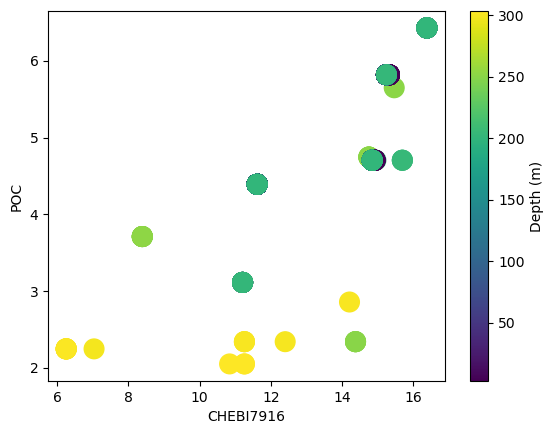

In [50]:
#plot up your results - here a metabolite versus POC data from the Close lab
sc = plt.scatter(df['CHEBI7916'],df['POC'],c= df['depth'],cmap='viridis',s=200)
plt.ylabel('POC' )
plt.xlabel('CHEBI7916')
# Add the colorbar, passing the 'sc' object
cbar = plt.colorbar(sc)

# Set a label for the colorbar
cbar.set_label('Depth (m)')

In [51]:
#Get a list of variables in a dataset
api.columns('tblBATS_Primary_Production')

['time',
 'lat',
 'lon',
 'depth',
 'time_out',
 'Lat_out',
 'Long_out',
 'pres',
 'temp',
 'salt',
 'lt1',
 'lt2',
 'lt3',
 'dark',
 't0',
 'pp',
 'Cruise_ID',
 'niskin_flag',
 'UNOLS']

In [52]:
targetTables=['tblBIOSSCOPE_survey_biogeochemical',
              'tblBIOSSCOPE_survey_biogeochemical',
              'tblAll_Basins_DOM_Data_Merged_2022',
            'tblBATS_Primary_Production',
            'tblModis_CHL',
             'tblWOA_Climatology']
    
targetVars=['Bact',
            'NO3_plus_NO2',
            'DOC',
            'pp',
            'chlor_a',
            'nitrate_WOA_clim']

df = api.match(
              sourceTable='tblBIOSSCOPE_survey_biogeochemical',
              sourceVar='Pressure',
              targetTables=targetTables,
              targetVars=targetVars,
              dt1='2018-07-01',
              dt2='2020-12-31',
              lat1=30,
              lat2=35,
              lon1=-60,
              lon2=-70,
              depth1=0,
              depth2=300,
              temporalTolerance=[30,30,30,30,0,0],
              latTolerance= [10,10,10,10,10,10],
              lonTolerance=[5,5,5,5,5,5],
              depthTolerance=[50,50,50,50,50,50]
              )

overall:   0%|          | 0/6 [00:00<?, ?it/s]


1: Bact matched.

2: NO3_plus_NO2 matched.

3: DOC matched.

4: pp matched.

5: chlor_a matched.

6: nitrate_WOA_clim matched.


In [53]:
df.head()

,time,lat,lon,depth,Pressure,Pressure_std,Bact,Bact_std,NO3_plus_NO2,NO3_plus_NO2_std,DOC,DOC_std,pp,pp_std,chlor_a,chlor_a_std,nitrate_WOA_clim,nitrate_WOA_clim_std
0,2018-07-03T18:20:00,31.6668,-64.1662,3.119,3.141,0.000000e+00,5.168333,0.983662,0.000000,0.000000,79.356307,3.329546,3.493333,1.634731,NaN,NaN,0.557424,0.672867
1,2018-07-03T18:20:00,31.6668,-64.1662,3.243,3.265,2.027826e-07,5.168333,0.983662,0.000000,0.000000,79.356307,3.329546,3.493333,1.634731,NaN,NaN,0.557424,0.672867
2,2018-07-03T18:20:00,31.6668,-64.1662,20.125,20.267,0.000000e+00,5.255000,1.006900,0.002727,0.012792,77.983797,5.162771,3.383750,1.419315,NaN,NaN,0.828857,1.151833
3,2018-07-03T18:20:00,31.6668,-64.1662,39.947,40.230,2.719418e-06,4.957143,1.133444,0.060667,0.117823,75.961435,6.508498,3.410000,1.501436,NaN,NaN,1.060869,1.502219
4,2018-07-03T18:20:00,31.6668,-64.1662,40.404,40.690,2.442110e-06,4.957143,1.133444,0.060667,0.117823,75.961435,6.508498,3.410000,1.501436,NaN,NaN,1.134291,1.622356


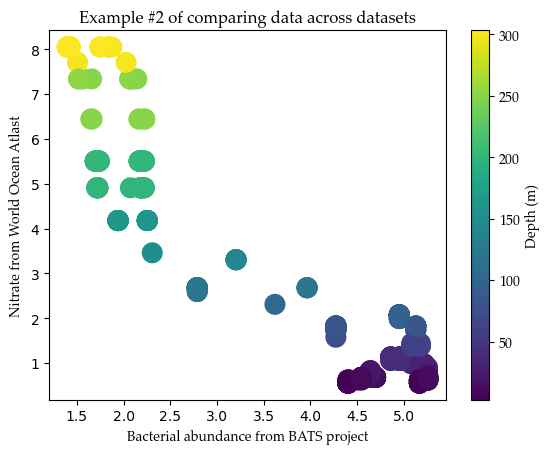

In [54]:
sc = plt.scatter(df['Bact'],df['nitrate_WOA_clim'],c= df['depth'],cmap='viridis',s=200)

plt.xlabel('Bacterial abundance from BATS project',**useFont)
plt.ylabel('Nitrate from World Ocean Atlast',**useFont)
plt.title('Example #2 of comparing data across datasets',**useFont)

# Add the colorbar, passing the 'sc' object
cbar = plt.colorbar(sc)

# Set a label for the colorbar
cbar.set_label('Depth (m)',**useFont)
for t in cbar.ax.get_yticklabels():
    t.set_fontname('Palatino Linotype') # Change font family

plt.savefig('BAvNO3.jpg', bbox_inches='tight')  # filename chosen here
plt.show()
        

In [55]:
#define some functions before moving on

In [56]:
def in_box(point, bbox):
    """
    Check if a point (lat, lon) is within a bounding box.
    Point: put both lat/lon into single variable: with latitude first [0] and then longitude [1]

    bbox format: (min_lon, min_lat, max_lon, max_lat)
    """
    min_lon, min_lat, max_lon, max_lat = bbox

    # Check if the point's latitude and longitude fall within the box's ranges
    if min_lat <= point[0] <= max_lat and min_lon <= point[1] <= max_lon:
        return True
    else:
        return False

In [57]:
def in_time(want,data):
    """
    want is the time window of interest (data after this time)
    data: start time for the data available 
    """
    date_string = data
    format_string = "%Y-%m-%dT%H:%M:%S.%fZ"
    date_object = datetime.strptime(date_string, format_string)
    dates = date_object.year

    if dates >= want:
        return True
    else:
        return False

In [58]:
# get all possible data in the vicinity of BATS:
BATS =[31.67, -64.17] #don't forget negative longitude!

In [59]:
allCruises = api.cruises()

In [60]:
#note name spelling
allCruises[allCruises['Nickname'] =='BIOSCOPE']

,ID,Nickname,Name,Ship_Name,Start_Time,End_Time,Lat_Min,Lat_Max,Lon_Min,Lon_Max,Chief_Name,Keywords,Unstructured_Cruise_Metadata
269,1426,BIOSCOPE,AE1712,Atlantic Explorer,2017-07-08T11:20:25.000Z,2017-07-13T00:05:01.000Z,31.570438,32.40006,-64.724842,-64.075833,"Carlson, Craig",NaN,NaN


In [61]:
allCruises['toFilter'] = None
allCruises['timeFilter'] = None

for idx,row in allCruises.iterrows():
    #print(idx)
    #are the data in the time window I want? First need to make sure time is not NaN
    if pd.notna(allCruises.loc[idx,'Start_Time'] ):
        if in_time(2016,allCruises.loc[idx,'Start_Time']):
            allCruises.loc[idx,'timeFilter'] = True
            allCruises.loc[idx,'toFilter'] = in_box(BATS,allCruises.loc[idx,['Lon_Min','Lat_Min','Lon_Max','Lat_Max']])
        else:
            allCruises.loc[idx,'timeFilter'] = False
            allCruises.loc[idx,'toFilter'] = in_box(BATS,allCruises.loc[idx,['Lon_Min','Lat_Min','Lon_Max','Lat_Max']])
    else:
        allCruises.loc[idx,'timeFilter'] = False

In [62]:
allCruises = allCruises[(allCruises['toFilter']==True) & (allCruises['timeFilter']==True)]
allCruises

,ID,Nickname,Name,Ship_Name,Start_Time,End_Time,Lat_Min,Lat_Max,Lon_Min,Lon_Max,Chief_Name,Keywords,Unstructured_Cruise_Metadata,toFilter,timeFilter
235,4108,Bermuda Atlantic Time-series Study (BATS)/Hydr...,AE1602,Atlantic Explorer,2016-03-07T12:56:59.000Z,2016-03-12T00:00:01.000Z,31.156313,32.386590,-64.681677,-63.585027,"Johnson, Rodney",NaN,NaN,True,True
236,4109,Bermuda Atlantic Time-series Study (BATS)/Hydr...,AE1603,Atlantic Explorer,2016-03-21T00:01:01.000Z,2016-03-25T23:59:59.000Z,31.173838,32.400443,-64.722427,-63.573460,"Johnson, Rodney",NaN,NaN,True,True
237,4110,Bermuda Atlantic Time-series Study (BATS)/Hydr...,AE1604,Atlantic Explorer,2016-04-03T00:01:14.000Z,2016-04-06T23:59:00.000Z,31.582387,32.400250,-64.762198,-64.084158,"GonÃ§alves, Afonso Neto",NaN,NaN,True,True
238,4111,Bermuda Atlantic Time-series Study (BATS)/Hydr...,AE1605,Atlantic Explorer,2016-04-14T11:26:01.000Z,2016-04-19T22:16:00.000Z,30.791340,32.400367,-64.724858,-63.485158,"Enright, Matthew",NaN,NaN,True,True
239,2404,Ocean Flux Program (OFP) Mooring,AE1606,Atlantic Explorer,2016-04-23T12:24:59.000Z,2016-04-28T16:19:01.000Z,31.498415,32.401378,-64.723635,-63.903342,"Conte, Maureen",NaN,NaN,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
931,6298,BATS 10356,EN629,R/V Endeavor,2019-02-17T00:00:00.000Z,2019-02-20T16:03:00.000Z,31.160400,32.386700,-64.681400,-63.594700,"Johnson, Rodney",NaN,NaN,True,True
932,6299,BATS 10357,EN631,R/V Endeavor,2019-03-11T00:00:00.000Z,2019-03-15T18:00:00.000Z,31.170300,32.385600,-64.745200,-63.594700,"Johnson, Rodney",NaN,NaN,True,True
1042,1754,Deep Coral Diversity at Emperor Seamount Chain...,FK190726,Falkor,2019-07-26T16:03:00.000Z,2019-08-26T16:15:00.000Z,21.236930,44.646672,-179.999222,179.998789,"Watling, Leslie",NaN,NaN,True,True
2810,5196,Transit,RR1709,Roger Revelle,2017-04-26T00:00:00.000Z,2017-05-15T15:23:00.000Z,13.428517,36.204297,-179.996830,179.999533,NaN,NaN,NaN,True,True


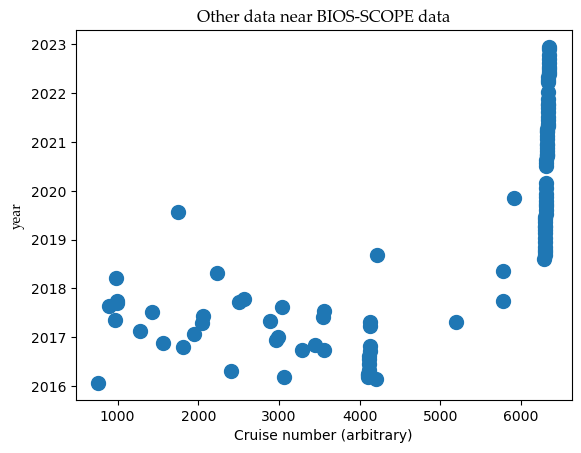

In [63]:
dates = pd.to_datetime(allCruises.Start_Time,format = "%Y-%m-%dT%H:%M:%S.%fZ").dt.date

useFont = {'fontname':'Palatino Linotype'}    
df = allCruises
sc = plt.scatter(df['ID'],dates,s=100)
plt.xlabel('Cruise number (arbitrary)')
plt.ylabel('year',**useFont)
plt.title('Other data near BIOS-SCOPE data',**useFont)
plt.savefig('otherData.jpg', bbox_inches='tight')  # filename chosen here
    
#mostly BATS cruises, with a few others in here